In [1]:
!pip install yfinance 

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import yfinance as yf
# Fetch 5 years of daily data for Apple
df = yf.download('AAPL', start='2021-01-01', end='2026-04-20')
df = df[['Close']] # Focus on the closing price

[*********************100%***********************]  1 of 1 completed


# ARIMA

In [4]:
# ADF Test
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Close'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: -0.9642325326702788
p-value: 0.7660851757081104


In [5]:
# If p-value < 0.05: The data is stationary.
# If p-value > 0.05: You must perform Differencing.

In [6]:
# Differencing
df['Diff'] = df['Close'].diff().dropna()

In [7]:
# Run ADF on the differenced data
result_diff = adfuller(df['Diff'].dropna())
print(f'ADF Statistic (Diff): {result_diff[0]}')
print(f'p-value (Diff): {result_diff[1]}')

ADF Statistic (Diff): -34.786563423676874
p-value (Diff): 0.0


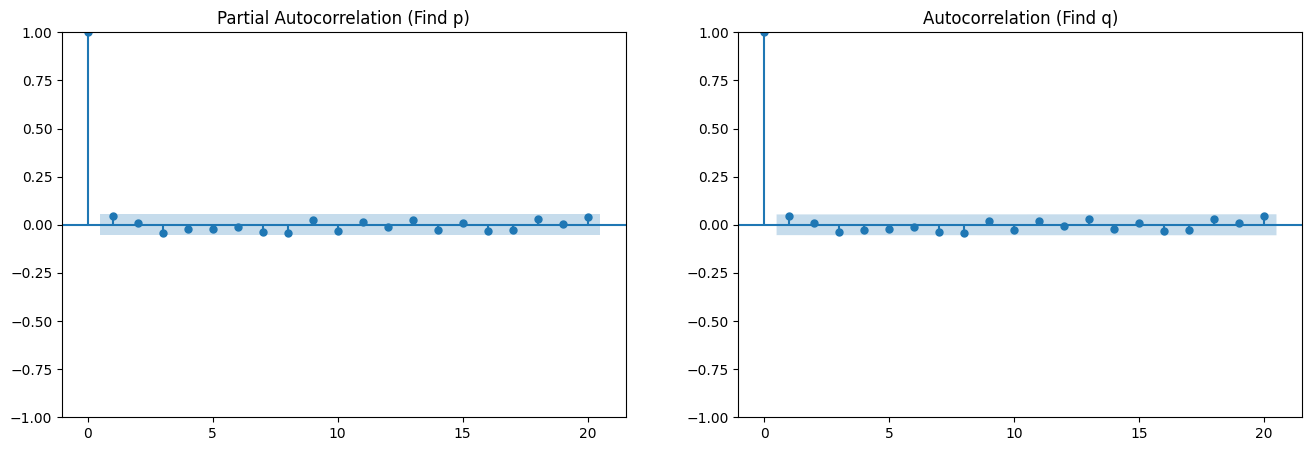

In [8]:
# # Visualizing $p$ and $q$
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# We use the differenced data (stationary series) for these plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# PACF helps identify the 'p' (AR) term
plot_pacf(df['Diff'].dropna(), ax=axes[0], lags=20)
axes[0].set_title('Partial Autocorrelation (Find p)')

# ACF helps identify the 'q' (MA) term
plot_acf(df['Diff'].dropna(), ax=axes[1], lags=20)
axes[1].set_title('Autocorrelation (Find q)')

plt.show()

In [9]:
# Model Fitting
from statsmodels.tsa.arima.model import ARIMA

# We fit the model on the original 'Close' price, 
# but tell the model to difference it (d=1) internally.
model = ARIMA(df['Close'], order=(1, 1, 1))
model_fit = model.fit()

# This summary is the most important part of Phase 2
print(model_fit.summary())

C:\Users\user\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   AAPL   No. Observations:                 1328
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3399.532
Date:                Wed, 22 Apr 2026   AIC                           6805.063
Time:                        00:22:32   BIC                           6820.635
Sample:                             0   HQIC                          6810.900
                               - 1328                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1115      0.448      0.249      0.803      -0.766       0.989
ma.L1         -0.0671      0.450     -0.149      0.881      -0.949       0.814
sigma2         9.8331      0.193     50.885      0.0

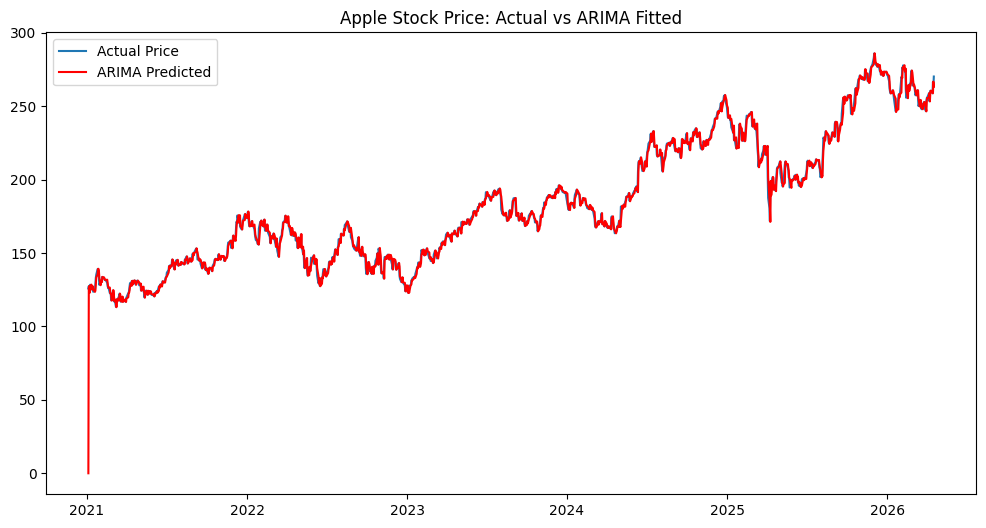

In [10]:
# Visualizing the Forecast
import matplotlib.pyplot as plt

# Plot the actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Actual Price')
plt.plot(model_fit.fittedvalues, color='red', label='ARIMA Predicted')
plt.title('Apple Stock Price: Actual vs ARIMA Fitted')
plt.legend()
plt.show()


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Use the fitted values to check historical accuracy
mae = mean_absolute_error(df['Close'], model_fit.fittedvalues)
rmse = np.sqrt(mean_squared_error(df['Close'], model_fit.fittedvalues))

print(f"ARIMA MAE: {mae:.2f}")
print(f"ARIMA RMSE: {rmse:.2f}")

ARIMA MAE: 2.31
ARIMA RMSE: 4.66


C:\Users\user\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\user\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


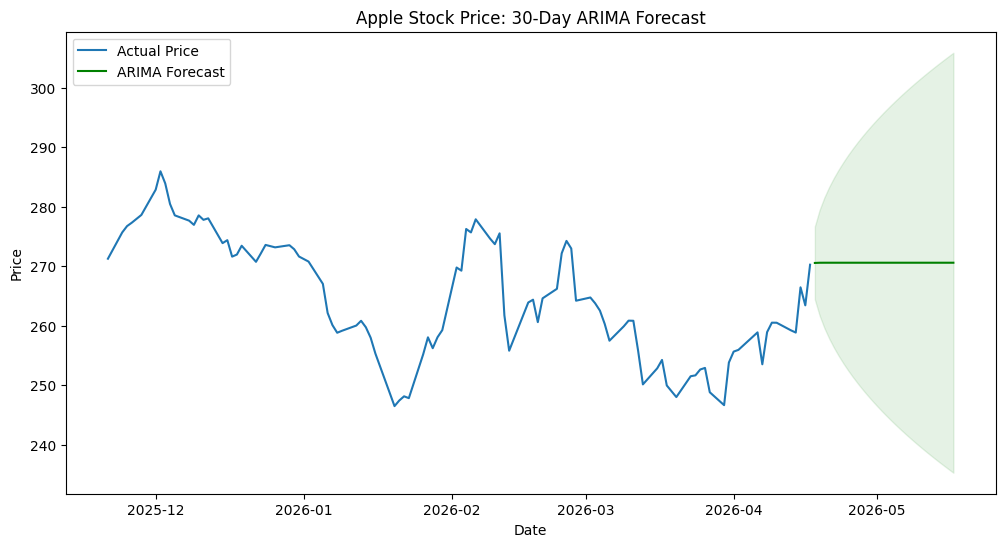

In [13]:
# import pandas as pd

# # Create a date range starting from the day after your last data point
# last_date = df.index[-1]
# forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)

# # Plotting again with correct dates
# plt.figure(figsize=(12, 6))
# plt.plot(df.index[-100:], df['Close'].tail(100), label='Actual Price') # Show last 100 days
# plt.plot(forecast_dates, forecast_df['mean'], color='green', label='ARIMA Forecast')
# plt.fill_between(forecast_dates, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'], color='green', alpha=0.1)

# plt.title('Apple Stock Price: 30-Day Forecast')
# plt.xlabel('Date')
# plt.ylabel('Price')
# plt.legend()
# plt.show()

# 1. Generate the forecast (replace 'model_fit' if you named your fitted model differently)
forecast_steps = 30
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_df = forecast.summary_frame()

# 2. Create the proper date range
last_date = df.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps)

# 3. Plot
plt.figure(figsize=(12, 6))
plt.plot(df.index[-100:], df['Close'].tail(100), label='Actual Price') 
plt.plot(forecast_dates, forecast_df['mean'], color='green', label='ARIMA Forecast')
plt.fill_between(forecast_dates, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'], color='green', alpha=0.1)

plt.title('Apple Stock Price: 30-Day ARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# LSTM

In [14]:
# Data Prepration

from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['Close']])



In [15]:
# Create training data (80%)
train_len = int(np.ceil(len(scaled_data) * 0.8))
train_data = scaled_data[0:train_len, :]

In [16]:
# Create the Windowed sequences (60 days)
x_train, y_train = [], []
for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])


In [17]:
# Convert to numpy and reshape to 3D [samples, time steps, features]
x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

print(f"X_train shape: {x_train.shape}") # Should be (samples, 60, 1)

X_train shape: (1003, 60, 1)


In [18]:
# Build and Train the model

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

model = Sequential([
    # Layer 1: LSTM with 50 units
    LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    Dropout(0.2),
    
    # Layer 2: LSTM
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    
    # Output Layers
    Dense(units=25),
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Train - Start with 10 epochs to see if loss decreases
model.fit(x_train, y_train, batch_size=32, epochs=10)

Epoch 1/10
32/32 [==============================] - 8s 62ms/step - loss: 0.0267
Epoch 2/10
32/32 [==============================] - 2s 58ms/step - loss: 0.0036
Epoch 3/10
32/32 [==============================] - 2s 57ms/step - loss: 0.0027
Epoch 4/10
32/32 [==============================] - 2s 60ms/step - loss: 0.0027
Epoch 5/10
32/32 [==============================] - 2s 58ms/step - loss: 0.0022
Epoch 6/10
32/32 [==============================] - 2s 57ms/step - loss: 0.0024
Epoch 7/10
32/32 [==============================] - 2s 57ms/step - loss: 0.0021
Epoch 8/10
32/32 [==============================] - 2s 57ms/step - loss: 0.0021
Epoch 9/10
32/32 [==============================] - 2s 57ms/step - loss: 0.0021
Epoch 10/10
32/32 [==============================] - 2s 59ms/step - loss: 0.0022


In [20]:
# Create the testing data set
# 'test_data' contains the last 20% of the scaled data
test_data = scaled_data[train_len - 60: , :]

x_test = []
y_test = df['Close'][train_len:].values # Actual prices for comparison

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

# Convert to numpy and reshape for LSTM
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

In [21]:
# from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# 1. Get the model's predicted price values 
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# 2. Calculate MSE (Mean Squared Error)
mse_lstm = mean_squared_error(y_test, predictions.flatten())

# 3. Calculate RMSE (Root Mean Squared Error)
rmse_lstm = np.sqrt(mse_lstm)

# 4. Calculate MAE (Mean Absolute Error)
mae_lstm = mean_absolute_error(y_test, predictions.flatten())

print(f"LSTM MSE: {mse_lstm:.2f}")
print(f"LSTM RMSE: {rmse_lstm:.2f}")
print(f"LSTM MAE: {mae_lstm:.2f}")

9/9 [==============================] - 1s 22ms/step
LSTM MSE: 70.41
LSTM RMSE: 8.39
LSTM MAE: 6.29


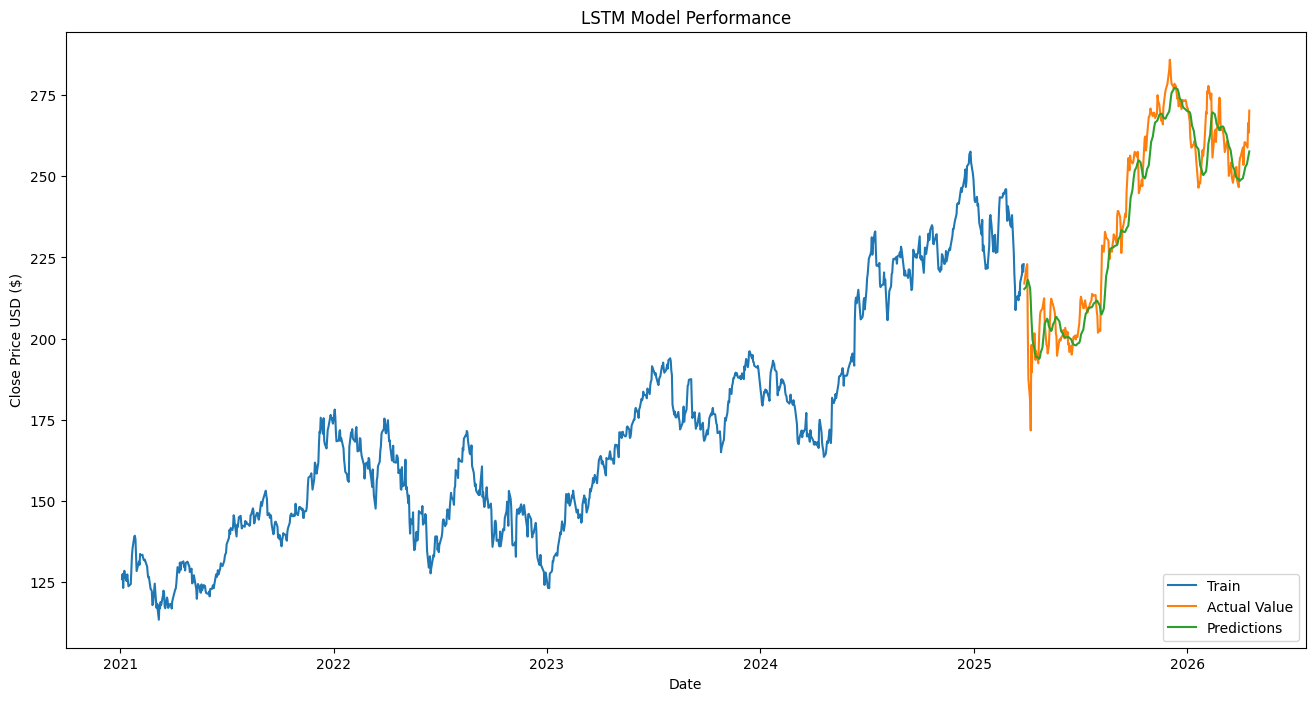

In [22]:
# Plot the data
train = df[:train_len]
valid = df[train_len:].copy()
valid['Predictions'] = predictions

plt.figure(figsize=(16,8))
plt.title('LSTM Model Performance')
plt.xlabel('Date')
plt.ylabel('Close Price USD ($)')
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Actual Value', 'Predictions'], loc='lower right')
plt.show()

# Comparison

In [23]:
import pandas as pd

# Assuming you calculated 'rmse_lstm' in the last step
# and 'rmse_arima' from earlier
results = {
    'Model': ['ARIMA', 'LSTM'],
    'RMSE': [rmse, rmse_lstm],
    'MAE': [mae, mae_lstm] # If you calculated MAE for both
}

comparison_df = pd.DataFrame(results)
print(comparison_df)

   Model     RMSE       MAE
0  ARIMA  4.66405  2.307592
1   LSTM  8.39089  6.288223


C:\Users\user\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


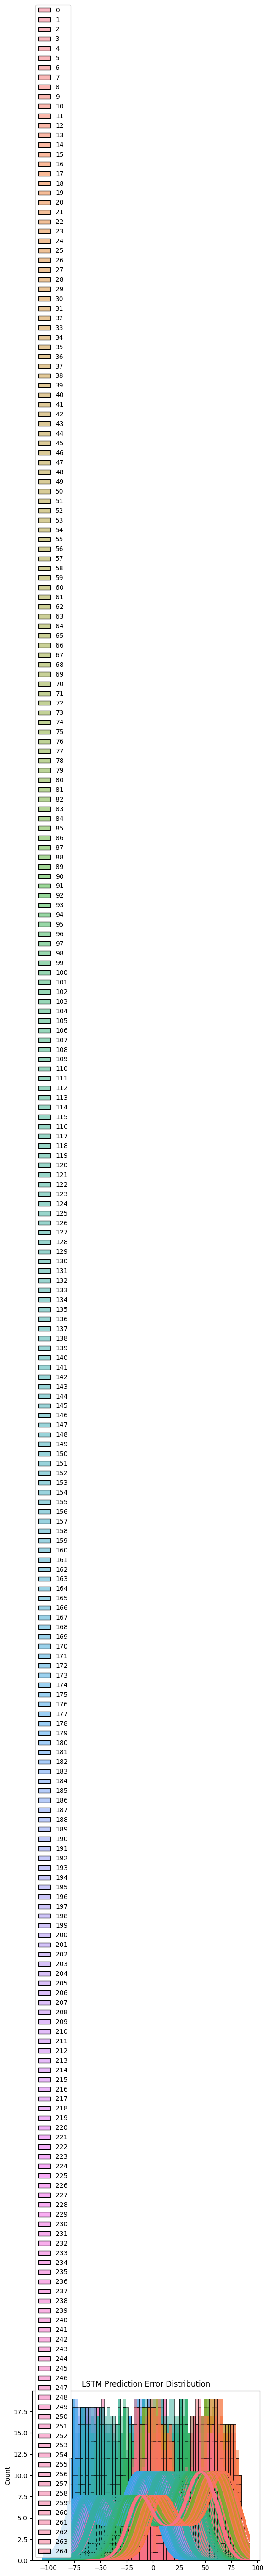

In [24]:
import seaborn as sns

residuals = y_test - predictions.flatten()
sns.histplot(residuals, kde=True)
plt.title('LSTM Prediction Error Distribution')
plt.show()